In [1]:
%pip install numpy==1.26.4
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install xgboost
%pip install lightgbm
%pip install catboost
%pip install optuna
%pip install shap==0.46.0
%pip install joblib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Machine Learning Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Hyperparameter Optimization
import optuna

# Model Explainability
import shap

# Save Model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load the datasets

df_2024 = pd.read_csv("year_2024.csv")

df_2025 = pd.read_csv("year_2025.csv")

# Merge the datasets

df = pd.concat([df_2024, df_2025], ignore_index=True)

print("2024 Shape :", df_2024.shape)
print("2025 Shape :", df_2025.shape)
print("Merged Shape :", df.shape)

print("\nColumns:\n")

print(df.columns.tolist())

df.head()

2024 Shape : (8939142, 9)
2025 Shape : (9487238, 9)
Merged Shape : (18426380, 9)

Columns:

['date', 'latitude', 'longitude', 'co_column', 'co_quality', 'year', 'month', 'day', 'day_of_week']


,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
0,2024-01-01,23.690218,73.982162,0.053744,1.0,2024,1,1,0
1,2024-01-01,23.691870,69.942146,0.039776,1.0,2024,1,1,0
2,2024-01-01,23.692059,70.382019,0.040581,1.0,2024,1,1,0
3,2024-01-01,23.692949,72.901031,0.046814,0.7,2024,1,1,0
4,2024-01-01,23.698761,70.938744,0.042255,0.7,2024,1,1,0


In [7]:
# ============================
# Convert Date
# ============================

df["date"] = pd.to_datetime(df["date"])

print("Date Type :", df["date"].dtype)


# ============================
# Missing Values
# ============================

missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage (%)": round(df.isnull().mean()*100,4)

})

print("\nMissing Values")
display(missing)


# ============================
# Duplicate Rows
# ============================

print("\nDuplicate Rows :", df.duplicated().sum())


# ============================
# Sort Dataset
# ============================

df = df.sort_values("date").reset_index(drop=True)

print("\nDataset Sorted Successfully")


# ============================
# Basic Statistics
# ============================

display(df.describe())

Date Type : datetime64[us]

Missing Values


,Missing Values,Percentage (%)
date,0,0.0
latitude,0,0.0
longitude,0,0.0
co_column,0,0.0
co_quality,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
day_of_week,0,0.0



Duplicate Rows : 0

Dataset Sorted Successfully


,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
count,18426380,1.842638e+07,1.842638e+07,1.842638e+07,1.842638e+07,1.842638e+07,1.842638e+07,1.842638e+07,1.842638e+07
mean,2025-01-09 09:10:44.884909,3.053524e+01,6.918616e+01,3.029908e-02,7.939960e-01,2.024515e+03,6.644920e+00,1.564732e+01,2.979071e+00
min,2024-01-01 00:00:00,2.369000e+01,6.087000e+01,1.091036e-03,7.000000e-01,2.024000e+03,1.000000e+00,1.000000e+00,0.000000e+00
25%,2024-07-15 00:00:00,2.731047e+01,6.500895e+01,2.523245e-02,7.000000e-01,2.024000e+03,4.000000e+00,8.000000e+00,1.000000e+00
50%,2025-01-13 00:00:00,3.053812e+01,6.910358e+01,3.047911e-02,7.000000e-01,2.025000e+03,7.000000e+00,1.600000e+01,3.000000e+00
75%,2025-07-08 00:00:00,3.378098e+01,7.330677e+01,3.533039e-02,1.000000e+00,2.025000e+03,9.000000e+00,2.300000e+01,5.000000e+00
max,2025-12-31 00:00:00,3.713000e+01,7.784000e+01,1.624519e-01,1.000000e+00,2.025000e+03,1.200000e+01,3.100000e+01,6.000000e+00
std,NaN,3.774298e+00,4.845210e+00,7.861528e-03,1.391530e-01,4.997788e-01,3.357577e+00,8.775772e+00,2.005804e+00


In [8]:
# Time Features

df["day_of_year"] = df["date"].dt.dayofyear

df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


# Cyclical Features

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)

df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)

df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 366)

df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 366)


# Spatial Features

df["lat_lon"] = df["latitude"] * df["longitude"]

df["lat_sq"] = df["latitude"] ** 2

df["lon_sq"] = df["longitude"] ** 2


# Distance from Dataset Center

CENTER_LAT = df["latitude"].mean()

CENTER_LON = df["longitude"].mean()

df["distance_center"] = np.sqrt(

    (df["latitude"] - CENTER_LAT) ** 2 +

    (df["longitude"] - CENTER_LON) ** 2

)


# Season (for analysis only)

df["season"] = df["month"].map({

    12: "Winter",
    1: "Winter",
    2: "Winter",

    3: "Spring",
    4: "Spring",
    5: "Spring",

    6: "Summer",
    7: "Summer",
    8: "Summer",

    9: "Autumn",
    10: "Autumn",
    11: "Autumn"

})


# Interaction Features

df["month_latitude"] = df["month"] * df["latitude"]

df["month_longitude"] = df["month"] * df["longitude"]

df["doy_latitude"] = df["day_of_year"] * df["latitude"]

df["doy_longitude"] = df["day_of_year"] * df["longitude"]


print("Total Columns :", len(df.columns))

print(df.dtypes)

Total Columns : 28
date               datetime64[us]
latitude                  float64
longitude                 float64
co_column                 float64
co_quality                float64
year                        int64
month                       int64
day                         int64
day_of_week                 int64
day_of_year                 int32
week_of_year                int32
quarter                     int32
is_weekend                  int32
month_sin                 float64
month_cos                 float64
day_sin                   float64
day_cos                   float64
doy_sin                   float64
doy_cos                   float64
lat_lon                   float64
lat_sq                    float64
lon_sq                    float64
distance_center           float64
season                        str
month_latitude            float64
month_longitude           float64
doy_latitude              float64
doy_longitude             float64
dtype: object


In [11]:
# Feature Selection

FEATURES = [

    "latitude",
    "longitude",
    "co_quality",

    "year",
    "month",
    "day",
    "day_of_week",

    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",

    "month_sin",
    "month_cos",

    "day_sin",
    "day_cos",

    "doy_sin",
    "doy_cos",

    "lat_lon",
    "lat_sq",
    "lon_sq",

    "distance_center",

    "month_latitude",
    "month_longitude",

    "doy_latitude",
    "doy_longitude"

]

TARGET = "co_column"

X = df[FEATURES]

y = df[TARGET]


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    shuffle=True

)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("Total Features :", len(FEATURES))

Training Shape : (14741104, 25)
Testing Shape  : (3685276, 25)
Total Features : 25


In [13]:
# XGBoost Training

xgb_model = XGBRegressor(

    n_estimators=500,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.80,

    colsample_bytree=0.80,

    min_child_weight=3,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)

start = time.time()

xgb_model.fit(

    X_train,

    y_train

)

xgb_train_time = time.time() - start

print("Training Completed")

print(f"Training Time : {xgb_train_time:.2f} sec")

Training Completed
Training Time : 662.26 sec


In [15]:
# Prediction

start = time.time()

xgb_pred = xgb_model.predict(X_test)

xgb_prediction_time = time.time() - start


# Evaluation Metrics

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)


# Results

print("XGBOOST RESULTS\n")

print(f"MAE             : {xgb_mae:.6f}")
print(f"RMSE            : {xgb_rmse:.6f}")
print(f"R²              : {xgb_r2:.6f}")
print(f"Training Time   : {xgb_train_time:.2f} sec")
print(f"Prediction Time : {xgb_prediction_time:.2f} sec")

XGBOOST RESULTS

MAE             : 0.002025
RMSE            : 0.002669
R²              : 0.884791
Training Time   : 662.26 sec
Prediction Time : 12.16 sec


In [17]:
# LightGBM Training

lgbm_model = LGBMRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1

)

start = time.time()

lgbm_model.fit(

    X_train,

    y_train

)

lgbm_train_time = time.time() - start

print("Training Completed")

print(f"Training Time : {lgbm_train_time:.2f} sec")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.634400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3481
[LightGBM] [Info] Number of data points in the train set: 14741104, number of used features: 25
[LightGBM] [Info] Start training from score 0.030299
Training Completed
Training Time : 342.61 sec


In [19]:
# Prediction

start = time.time()

lgbm_pred = lgbm_model.predict(X_test)

lgbm_prediction_time = time.time() - start


# Evaluation Metrics

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

lgbm_r2 = r2_score(y_test, lgbm_pred)


# Results

print("LIGHTGBM RESULTS\n")

print(f"MAE             : {lgbm_mae:.6f}")
print(f"RMSE            : {lgbm_rmse:.6f}")
print(f"R²              : {lgbm_r2:.6f}")
print(f"Training Time   : {lgbm_train_time:.2f} sec")
print(f"Prediction Time : {lgbm_prediction_time:.2f} sec")

LIGHTGBM RESULTS

MAE             : 0.002290
RMSE            : 0.003034
R²              : 0.851085
Training Time   : 342.61 sec
Prediction Time : 21.75 sec


In [21]:
# CatBoost Training

cat_model = CatBoostRegressor(

    iterations=500,

    learning_rate=0.05,

    depth=8,

    loss_function="RMSE",

    random_seed=42,

    verbose=False

)

start = time.time()

cat_model.fit(

    X_train,

    y_train

)

cat_train_time = time.time() - start

print("Training Completed")

print(f"Training Time : {cat_train_time:.2f} sec")

Training Completed
Training Time : 980.73 sec


In [23]:
# Prediction

start = time.time()

cat_pred = cat_model.predict(X_test)

cat_prediction_time = time.time() - start


# Evaluation Metrics

cat_mae = mean_absolute_error(y_test, cat_pred)

cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))

cat_r2 = r2_score(y_test, cat_pred)


# Results

print("CATBOOST RESULTS\n")

print(f"MAE             : {cat_mae:.6f}")
print(f"RMSE            : {cat_rmse:.6f}")
print(f"R²              : {cat_r2:.6f}")
print(f"Training Time   : {cat_train_time:.2f} sec")
print(f"Prediction Time : {cat_prediction_time:.2f} sec")

CATBOOST RESULTS

MAE             : 0.002333
RMSE            : 0.003105
R²              : 0.844056
Training Time   : 980.73 sec
Prediction Time : 1.98 sec


In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [27]:
# HistGradientBoostingRegressor Training

hgb_model = HistGradientBoostingRegressor(

    learning_rate=0.05,

    max_depth=8,

    max_iter=500,

    min_samples_leaf=20,

    random_state=42

)

start = time.time()

hgb_model.fit(

    X_train,

    y_train

)

hgb_train_time = time.time() - start

print("Training Completed")

print(f"Training Time : {hgb_train_time:.2f} sec")

Training Completed
Training Time : 332.06 sec


In [30]:
# Prediction

start = time.time()

hgb_pred = hgb_model.predict(X_test)

hgb_prediction_time = time.time() - start


# Evaluation Metrics

hgb_mae = mean_absolute_error(y_test, hgb_pred)

hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_pred))

hgb_r2 = r2_score(y_test, hgb_pred)


# Results

print("HISTGRADIENTBOOSTING RESULTS\n")

print(f"MAE             : {hgb_mae:.6f}")
print(f"RMSE            : {hgb_rmse:.6f}")
print(f"R²              : {hgb_r2:.6f}")
print(f"Training Time   : {hgb_train_time:.2f} sec")
print(f"Prediction Time : {hgb_prediction_time:.2f} sec")

HISTGRADIENTBOOSTING RESULTS

MAE             : 0.002549
RMSE            : 0.003396
R²              : 0.813450
Training Time   : 371.43 sec
Prediction Time : 22.53 sec


In [32]:
comparison = pd.DataFrame({

    "Model": [

        "XGBoost",
        "LightGBM",
        "CatBoost",
        "HistGradientBoosting"

    ],

    "MAE": [

        xgb_mae,
        lgbm_mae,
        cat_mae,
        hgb_mae

    ],

    "RMSE": [

        xgb_rmse,
        lgbm_rmse,
        cat_rmse,
        hgb_rmse

    ],

    "R²": [

        xgb_r2,
        lgbm_r2,
        cat_r2,
        hgb_r2

    ],

    "Training Time (sec)": [

        xgb_train_time,
        lgbm_train_time,
        cat_train_time,
        hgb_train_time

    ],

    "Prediction Time (sec)": [

        xgb_prediction_time,
        lgbm_prediction_time,
        cat_prediction_time,
        hgb_prediction_time

    ]

})

comparison = comparison.sort_values("R²", ascending=False)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,MAE,RMSE,R²,Training Time (sec),Prediction Time (sec)
0,XGBoost,0.002025,0.002669,0.884791,662.260930,12.162230
1,LightGBM,0.002290,0.003034,0.851085,342.610461,21.747726
2,CatBoost,0.002333,0.003105,0.844056,980.730356,1.976725
3,HistGradientBoosting,0.002549,0.003396,0.813450,371.426912,22.530996


In [40]:
# Optuna Hyperparameter Tuning

from sklearn.metrics import r2_score

# Create tuning dataset

X_train_tune = X_train.sample(
    n=1000000,
    random_state=42
)

y_train_tune = y_train.loc[X_train_tune.index]

X_test_tune = X_test.sample(
    n=200000,
    random_state=42
)

y_test_tune = y_test.loc[X_test_tune.index]

print("Training Sample :", X_train_tune.shape)
print("Testing Sample  :", X_test_tune.shape)


# Objective Function

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 450, 550),

        "max_depth": trial.suggest_int("max_depth", 7, 9),

        "learning_rate": trial.suggest_float("learning_rate", 0.04, 0.06),

        "subsample": trial.suggest_float("subsample", 0.75, 0.85),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.75, 0.85),

        "min_child_weight": trial.suggest_int("min_child_weight", 2, 4),

        "objective": "reg:squarederror",

        "random_state": 42,

        "n_jobs": -1

    }

    model = XGBRegressor(**params)

    model.fit(
        X_train_tune,
        y_train_tune
    )

    pred = model.predict(X_test_tune)

    score = r2_score(
        y_test_tune,
        pred
    )

    return score


study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=25
)

print("\nBest R² :", study.best_value)

print("\nBest Parameters:\n")

print(study.best_params)

[I 2026-07-13 23:51:46,763] A new study created in memory with name: no-name-5e2ed4f6-b0c1-4133-b890-d86f45df7ce4


Training Sample : (1000000, 25)
Testing Sample  : (200000, 25)


[I 2026-07-13 23:52:26,773] Trial 0 finished with value: 0.8770419923245644 and parameters: {'n_estimators': 543, 'max_depth': 7, 'learning_rate': 0.05890808120780634, 'subsample': 0.7520972185216701, 'colsample_bytree': 0.7936217536815954, 'min_child_weight': 4}. Best is trial 0 with value: 0.8770419923245644.
[I 2026-07-13 23:53:06,704] Trial 1 finished with value: 0.8726553057398887 and parameters: {'n_estimators': 484, 'max_depth': 7, 'learning_rate': 0.05441239505421449, 'subsample': 0.8067879149547592, 'colsample_bytree': 0.7949045213919426, 'min_child_weight': 4}. Best is trial 0 with value: 0.8770419923245644.
[I 2026-07-13 23:53:58,978] Trial 2 finished with value: 0.8921300962022995 and parameters: {'n_estimators': 502, 'max_depth': 9, 'learning_rate': 0.04128098594353276, 'subsample': 0.7905303950459891, 'colsample_bytree': 0.7528595576069095, 'min_child_weight': 4}. Best is trial 2 with value: 0.8921300962022995.
[I 2026-07-13 23:54:42,490] Trial 3 finished with value: 0.87


Best R² : 0.8944629117410496

Best Parameters:

{'n_estimators': 492, 'max_depth': 9, 'learning_rate': 0.04950334435711133, 'subsample': 0.848334044674878, 'colsample_bytree': 0.7593670381513774, 'min_child_weight': 3}


In [42]:
# Final Tuned XGBoost

best_xgb = XGBRegressor(

    **study.best_params,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)

start = time.time()

best_xgb.fit(
    X_train,
    y_train
)

best_train_time = time.time() - start

print("Training Completed")

print(f"Training Time : {best_train_time:.2f} sec")

Training Completed
Training Time : 629.04 sec


In [44]:
# Prediction

start = time.time()

best_pred = best_xgb.predict(X_test)

best_prediction_time = time.time() - start


# Evaluation Metrics

best_mae = mean_absolute_error(y_test, best_pred)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

best_r2 = r2_score(y_test, best_pred)


# Results

print("TUNED XGBOOST RESULTS\n")

print(f"MAE             : {best_mae:.6f}")

print(f"RMSE            : {best_rmse:.6f}")

print(f"R²              : {best_r2:.6f}")

print(f"Training Time   : {best_train_time:.2f} sec")

print(f"Prediction Time : {best_prediction_time:.2f} sec")

TUNED XGBOOST RESULTS

MAE             : 0.001931
RMSE            : 0.002535
R²              : 0.896074
Training Time   : 629.04 sec
Prediction Time : 14.61 sec


In [46]:
comparison_xgb = pd.DataFrame({

    "Model": [

        "Baseline XGBoost",

        "Tuned XGBoost"

    ],

    "MAE": [

        xgb_mae,

        best_mae

    ],

    "RMSE": [

        xgb_rmse,

        best_rmse

    ],

    "R²": [

        xgb_r2,

        best_r2

    ],

    "Training Time (sec)": [

        xgb_train_time,

        best_train_time

    ],

    "Prediction Time (sec)": [

        xgb_prediction_time,

        best_prediction_time

    ]

})

comparison_xgb

,Model,MAE,RMSE,R²,Training Time (sec),Prediction Time (sec)
0,Baseline XGBoost,0.002025,0.002669,0.884791,662.260930,12.162230
1,Tuned XGBoost,0.001931,0.002535,0.896074,629.041893,14.612327


In [48]:
# Feature Importance

importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance": best_xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.reset_index(drop=True, inplace=True)

importance

,Feature,Importance
0,lat_sq,0.241593
1,latitude,0.133947
2,lat_lon,0.112465
3,longitude,0.074404
4,lon_sq,0.055086
5,month_cos,0.052807
6,week_of_year,0.039833
7,doy_cos,0.027670
8,distance_center,0.026645
9,month_sin,0.025517


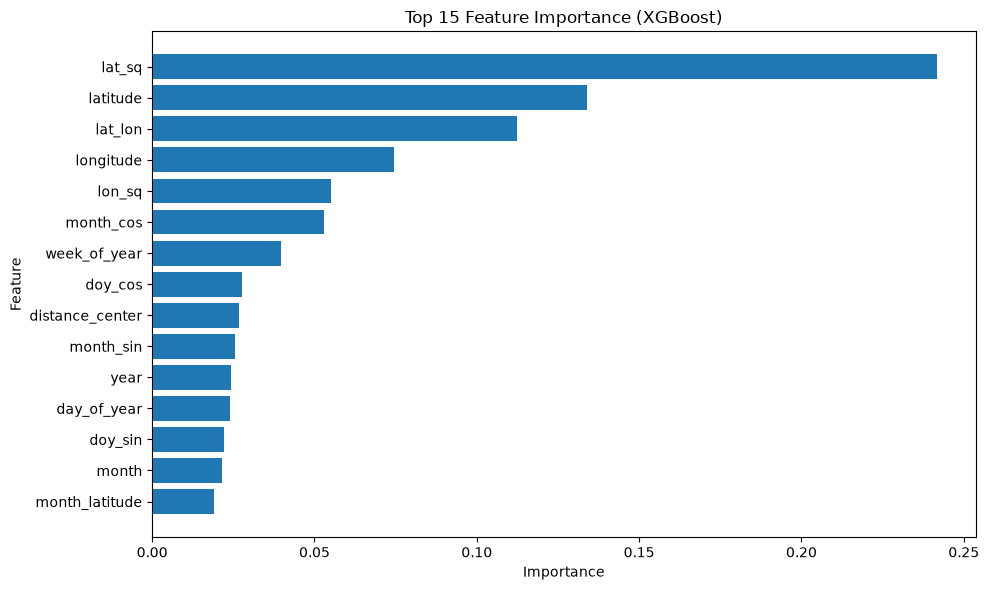

In [50]:
# Top 15 Important Features

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"][:15][::-1],

    importance["Importance"][:15][::-1]

)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 15 Feature Importance (XGBoost)")

plt.tight_layout()

plt.show()

PermutationExplainer explainer: 5001it [22:19,  3.73it/s]                          


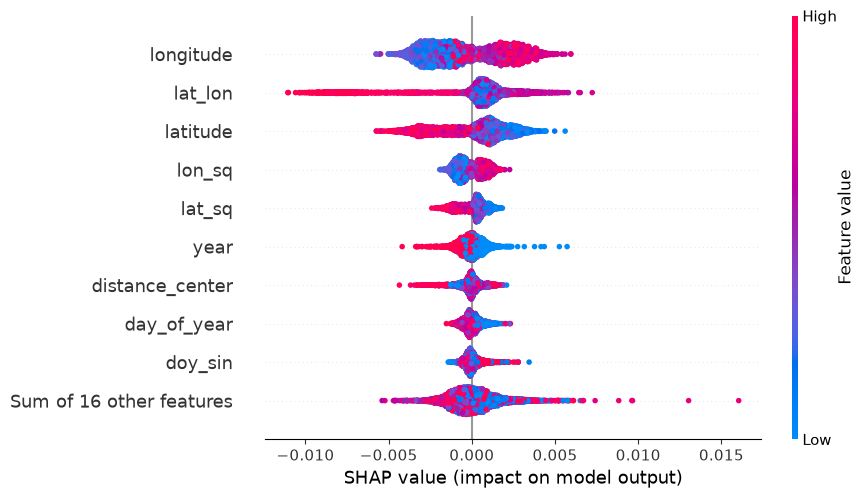

In [52]:
sample = X_test.sample(
    n=5000,
    random_state=42
)

explainer = shap.Explainer(
    best_xgb.predict,
    sample
)

shap_values = explainer(sample)

shap.plots.beeswarm(shap_values)

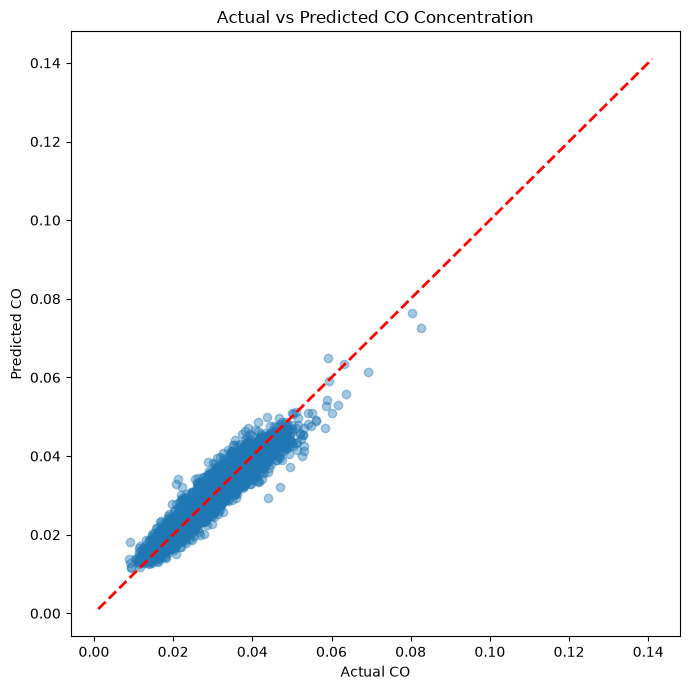

In [54]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test.sample(5000, random_state=42),
    pd.Series(best_pred, index=y_test.index).loc[y_test.sample(5000, random_state=42).index],
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual CO")

plt.ylabel("Predicted CO")

plt.title("Actual vs Predicted CO Concentration")

plt.tight_layout()

plt.show()

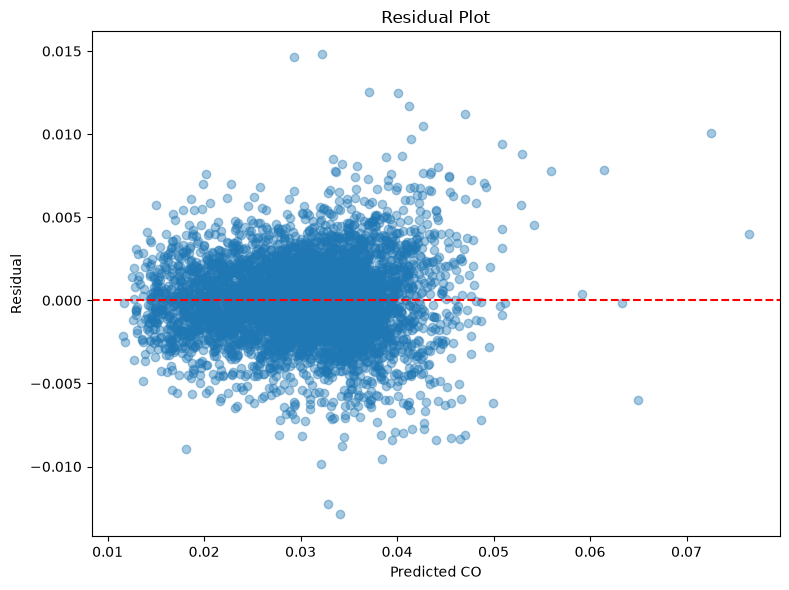

In [56]:
# Residual Plot

sample_idx = y_test.sample(5000, random_state=42).index

actual = y_test.loc[sample_idx]

predicted = pd.Series(best_pred, index=y_test.index).loc[sample_idx]

residual = actual - predicted

plt.figure(figsize=(8,6))

plt.scatter(predicted, residual, alpha=0.4)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted CO")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.show()

In [58]:
comparison.to_csv("Model_Comparison.csv", index=False)

importance.to_csv("Feature_Importance.csv", index=False)

joblib.dump(best_xgb, "Best_XGBoost_Model.pkl")

['Best_XGBoost_Model.pkl']